# W3 EDA — 서울 기상 × 패션 수요

| 항목 | 내용 |
|---|---|
| 주차 | **W3 (Phase 2: EDA·STL 분해·시차 상관)** |
| 입력 | `data/raw/kma_asos`(W1 관측), `kma_forecast`(W2·W3), `kma_warning`(W4), `datalab_category`(T1), `datalab_keyword`(T3), `datalab_search`(T4) |
| 범위 밖 | 이벤트 윈도우 룰북(W4), 모델 피처·학습(W5~) |

## 이 노트북이 답하려는 질문

1. **데이터를 그대로 믿어도 되는가?** 결측 규약, 배치 스케일, 희소 키워드 (→ §1·§2)
2. **수요의 대부분은 계절이 설명하는가?** 그렇다면 날씨 효과는 어디에 남는가 (→ §3·§5)
3. **원 시계열 상관이 왜 위험한가?** 같은 데이터로 가짜 상관을 직접 확인한다 (→ §4)
4. **날씨는 수요를 며칠 앞서는가?** STL 잔차끼리의 시차 상관 (→ §6)
5. **핵심 가설: 절대 기온보다 Δt·일교차가 더 잘 설명하는가?** (→ §7)
6. **한파 이벤트 임계값은 몇 ℃가 적절한가?** 규칙 기반 탐지를 실제 특보 이력과 대조 (→ §8)

> 원칙: 모든 차트 아래에 **해석** 셀을 둔다. `🤔` 셀은 본인이 직접 확인하고 채울 질문이다.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from statsmodels.tsa.seasonal import MSTL, STL
from statsmodels.tsa.stattools import acf

# 노트북은 notebooks/ 에서 실행된다고 가정한다
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"

plt.rcParams["font.family"] = "AppleGothic"   # macOS 한글 폰트. Windows 는 'Malgun Gothic'
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

CATS = yaml.safe_load((ROOT / "configs" / "categories.yaml").read_text(encoding="utf-8"))
print(ROOT)

/Users/kakao/weather_fit


---
## 1. 기상 데이터 (W1 관측) 품질 점검과 파생 변수

**관측(W1)을 EDA 기준으로 쓰는 이유**: EDA와 이벤트 정의는 "그날 실제로 어땠는가"를 기준으로 해야 한다.
예보(W2·W3)는 "그날 알 수 있었던 정보"라 **모델 입력**용이다 (docs/datasets.md §1).

> 📝 리뷰 노트 — `data/02_intermediate/daily_weather.csv` 는 `raw_temp.csv`(**중기 기온예보**)에서 만든 것이라
> 일교차·Δt가 예보 기준이다(리드타임 3일 때문에 2023-01-04부터 시작). EDA에서는 관측 기준 테이블을 따로 쓰고,
> 예보 테이블은 W5 모델 입력으로 남겨두는 것을 제안한다.

In [2]:
asos = pd.concat(
    [pd.read_csv(f, parse_dates=["date"]) for f in sorted((RAW / "kma_asos").glob("*.csv"))],
    ignore_index=True,
).sort_values("date")

print(asos.shape, asos["date"].min().date(), "~", asos["date"].max().date())
print("날짜 중복:", asos["date"].duplicated().sum())
print("달력 대비 빠진 날:", len(pd.date_range(asos["date"].min(), asos["date"].max())) - asos["date"].nunique())

check = ["t_max", "t_min", "t_avg", "precip_mm", "humidity", "wind", "weather_code"]
asos[check].isna().sum().to_frame("결측수").T

(1308, 66) 2023-01-01 ~ 2026-07-31
날짜 중복: 0
달력 대비 빠진 날: 0


,t_max,t_min,t_avg,precip_mm,humidity,wind,weather_code
결측수,0,0,0,754,0,5,1308


**해석** — 날짜는 1,308일로 빠짐없이 채워져 있다. 결측은 두 가지다.

- `precip_mm` 754건(57.6%): 결측이 아니라 **무강수**다. `RN_DAY=-9.0` 이 수집기에서 NaN으로 바뀐 것이므로 processed 단계에서 0으로 채운다.
- `weather_code` 1,308건(100%): 수집 단계에서 비워둔 컬럼이다. 아래에서 `CA_TOT`(운량)·`RN_DAY`·`SD_NEW`(신적설)로 파생한다.
- `wind` 5건은 진짜 결측이다. 체감온도 계산에만 쓰이므로 앞뒤 값으로 보간한다.

In [3]:
def build_weather_daily(asos: pd.DataFrame) -> pd.DataFrame:
    """W1 관측 → 분석용 일별 기상 테이블. 나중에 src/transform 으로 옮길 후보."""
    w = asos[["date", "t_max", "t_min", "t_avg", "precip_mm", "humidity", "wind", "CA_TOT", "SD_NEW"]].copy()
    w = w.set_index("date").asfreq("D")

    w["precip_mm"] = w["precip_mm"].fillna(0.0)                 # RN_DAY=-9 는 무강수
    w["snow_cm"] = w["SD_NEW"].where(w["SD_NEW"] >= 0, 0.0)     # -9 는 적설 없음
    w["wind"] = w["wind"].interpolate(limit=3)

    # 파생 변수 — 이 프로젝트 가설의 실체
    w["dtr"] = w["t_max"] - w["t_min"]                          # 일교차
    w["dt_min"] = w["t_min"].diff()                             # 전일 대비 최저기온 변화
    w["dt_max"] = w["t_max"].diff()

    # 체감온도: 기상청 겨울철 공식(기온 ≤10℃, 풍속 ≥4.8km/h). 그 외에는 평균기온을 그대로 쓴다.
    v = w["wind"] * 3.6
    wc = 13.12 + 0.6215 * w["t_avg"] - 11.37 * v**0.16 + 0.3965 * v**0.16 * w["t_avg"]
    w["feels_like"] = np.where((w["t_avg"] <= 10) & (v >= 4.8), wc, w["t_avg"])

    # 날씨 코드: 눈 > 비 > 운량(기상청 기준 0~5 맑음, 6~8 구름많음, 9~10 흐림)
    w["weather_code"] = np.select(
        [w["snow_cm"] > 0, w["precip_mm"] >= 0.1, w["CA_TOT"] >= 9, w["CA_TOT"] >= 6],
        ["눈", "비", "흐림", "구름많음"],
        default="맑음",
    )
    return w.drop(columns=["SD_NEW"])


wd = build_weather_daily(asos)
wd[["t_min", "t_max", "dtr", "dt_min", "feels_like", "precip_mm", "snow_cm"]].describe().round(1)

,t_min,t_max,dtr,dt_min,feels_like,precip_mm,snow_cm
count,1308.0,1308.0,1308.0,1307.0,1308.0,1308.0,1308.0
mean,10.2,18.9,8.8,0.0,13.3,4.0,0.1
std,11.0,10.7,3.2,2.6,12.0,12.8,0.9
min,-17.3,-8.2,1.0,-13.6,-23.0,0.0,0.0
25%,0.7,9.4,6.5,-1.5,2.7,0.0,0.0
50%,10.9,20.9,8.6,0.0,15.5,0.0,0.0
75%,20.0,27.9,11.1,1.4,23.7,0.5,0.0
max,29.3,38.0,21.1,10.2,32.8,128.8,19.3


**체감온도 정의를 이렇게 정한 이유** — 기상청은 겨울(바람)과 여름(습도) 체감온도 공식을 따로 쓴다.
이 프로젝트에서 체감온도가 의미 있게 달라지는 구간은 겨울 한파라서 겨울 공식만 적용했다.
여름 공식(습구온도 기반)은 필요하면 W5 피처 단계에서 추가한다.

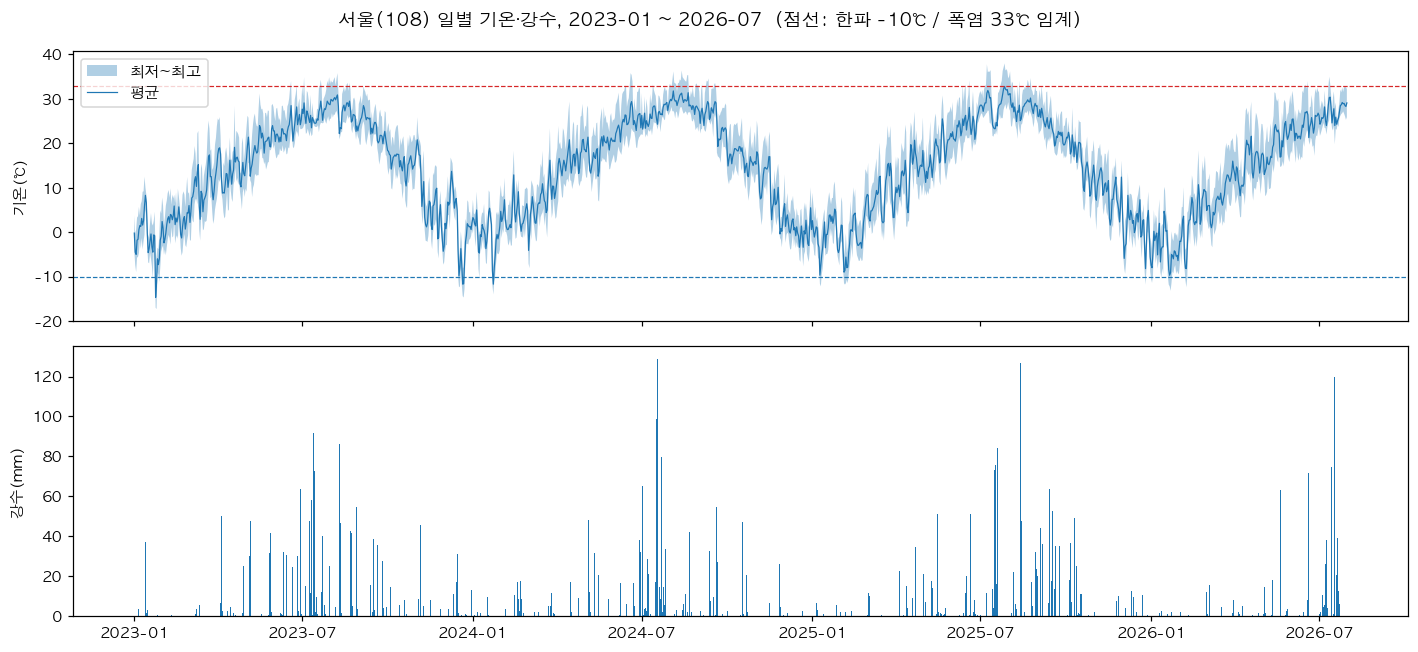

dtr      dt_min     
    mean  std   mean  std
월                        
1    8.3  2.5   -0.0  3.3
2    9.0  2.9    0.2  2.9
3   10.6  3.1    0.1  3.1
4   10.9  3.7    0.2  2.6
5   10.1  3.3    0.2  2.2
6    9.2  3.0    0.2  1.5
7    6.1  2.5    0.1  1.2
8    6.7  1.9   -0.1  1.2
9    7.5  2.5   -0.2  1.7
10   8.5  3.1   -0.2  2.6
11   9.2  3.0   -0.4  3.5
12   8.0  2.4   -0.1  3.6

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].fill_between(wd.index, wd["t_min"], wd["t_max"], alpha=0.35, label="최저~최고")
axes[0].plot(wd.index, wd["t_avg"], lw=0.8, label="평균")
axes[0].axhline(-10, color="tab:blue", ls="--", lw=0.8)
axes[0].axhline(33, color="tab:red", ls="--", lw=0.8)
axes[0].set_ylabel("기온(℃)"); axes[0].legend(loc="upper left")
axes[1].bar(wd.index, wd["precip_mm"], width=1.0, color="tab:blue")
axes[1].set_ylabel("강수(mm)")
fig.suptitle("서울(108) 일별 기온·강수, 2023-01 ~ 2026-07  (점선: 한파 -10℃ / 폭염 33℃ 임계)")
plt.tight_layout(); plt.show()

m = wd.groupby(wd.index.month)[["dtr", "dt_min"]].agg(["mean", "std"]).round(1)
m.index.name = "월"
m

**해석** — 기온은 사인 곡선에 가까운 강한 연 주기를 보인다. **-10℃ 선 아래로 내려가는 날도 드물다**(§8에서 정량화).
일교차는 **봄(3~5월, 평균 10.1~10.9℃)에 가장 크고 장마철(7~8월, 6.1~6.7℃)에 가장 작다.** 가을(10~11월)은 8.5~9.2℃로 봄보다 작다.
그래서 환절기 정의 "일교차 ≥10℃가 5일 중 3일"은 봄에는 쉽게 걸리고 가을에는 잘 안 걸릴 수 있다(W4 이벤트 정의 시 확인).
**일교차도 자체 계절성을 가지므로 수요와 비교하려면 계절 성분을 먼저 빼야 한다.**
Δt_min의 월별 표준편차는 겨울(11~1월 3.3~3.6℃)이 여름(7~8월 1.2℃)의 약 3배다. 기온 급변은 겨울에 몰려 있다.

### 1.1 예보 vs 관측: 모델 입력의 오차 크기 미리 보기

W5에서 모델 입력으로 쓸 **D-3 발표 예보**가 관측과 얼마나 다른지 확인한다. 오차가 크면
"관측으로 찾은 날씨 효과"가 예보 기반 모델에서는 약해질 수 있다.

In [5]:
fc = pd.concat(
    [pd.read_csv(f, parse_dates=["tmfc", "target_date"]) for f in sorted((RAW / "kma_forecast").glob("*.csv"))],
    ignore_index=True,
)
temp = fc[fc["src"] == "temp"].copy()

# 조인 규칙: 대상일 D 에 대해 tmfc < D 인 발표분 중 가장 최신 (실제로는 D-3 18시)
temp = temp[temp["tmfc"] < temp["target_date"]]
latest = temp.sort_values("tmfc").groupby("target_date").tail(1).set_index("target_date")
latest["lead_days"] = (latest.index - latest["tmfc"].dt.normalize()).dt.days

# 리드타임이 바뀐 시점(아래 출력으로 확인)을 기준으로 예보를 두 기간으로 나눠 다룬다
LEAD_CHANGE = pd.Timestamp("2024-12-02")
latest["fcst_period"] = np.where(latest.index < LEAD_CHANGE, "A: ~2024-12-01 (D-3)", "B: 2024-12-02~ (D-4)")

cmp = latest[["t_min", "t_max", "lead_days", "fcst_period"]].join(wd[["t_min", "t_max"]], rsuffix="_obs").dropna()

def forecast_error(d: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "일수": len(d),
        "t_min MAE": (d.t_min - d.t_min_obs).abs().mean(), "t_max MAE": (d.t_max - d.t_max_obs).abs().mean(),
        "t_min bias": (d.t_min - d.t_min_obs).mean(), "t_max bias": (d.t_max - d.t_max_obs).mean(),
        "Δt_min corr": d.t_min.diff().corr(d.t_min_obs.diff()),
    })

err = pd.concat({p: forecast_error(g) for p, g in cmp.groupby("fcst_period")} | {"전체": forecast_error(cmp)}, axis=1).T.round(2)
print("선택된 리드타임 분포:", latest["lead_days"].value_counts().to_dict())
print(latest.groupby([latest.index.year, "lead_days"]).size().unstack(fill_value=0).loc[:, [3, 4]].rename_axis(index="대상연도", columns="리드타임(일)"))
print("리드타임 4일이 처음 선택된 대상일:", latest.index[latest["lead_days"] == 4].min().date())

# 수집 누락인지, 예보 상품 변경인지: 발표시각별 발표 횟수와 최소 리드타임
temp["lead"] = (temp["target_date"] - temp["tmfc"].dt.normalize()).dt.days
print(temp.groupby([temp["tmfc"].dt.year.rename("발표연도"), temp["tmfc"].dt.hour.rename("발표시")]).agg(
    발표횟수=("tmfc", "nunique"), 최소리드=("lead", "min"), 최대리드=("lead", "max")).unstack())
err

선택된 리드타임 분포: {3: 698, 4: 611, 8: 1, 7: 1, 9: 1, 5: 1, 6: 1, 10: 1}
리드타임(일)    3    4
대상연도             
2023     362    0
2024     336   30
2025       0  365
2026       0  216
리드타임 4일이 처음 선택된 대상일: 2024-12-02
     발표횟수      최소리드    최대리드    
발표시    6    18   6  18   6   18
발표연도                           
2023  365  365    3  3   10  10
2024  366  366    3  3   10  10
2025  365  365    4  5   10  10
2026  212  212    4  5   10  10


,일수,t_min MAE,t_max MAE,t_min bias,t_max bias,Δt_min corr
A: ~2024-12-01 (D-3),697.0,1.13,1.32,0.42,-0.30,0.70
B: 2024-12-02~ (D-4),607.0,1.42,1.78,0.18,-0.43,0.62
전체,1304.0,1.27,1.53,0.31,-0.36,0.66


**해석**
- 예보 기온의 오차는 전체 기준 **MAE t_min 1.3℃ / t_max 1.5℃** 이다. Δt_min의 표준편차가 2.6℃라서, **전일 대비 변화량 같은 작은 신호는 예보 오차와 크기가 비슷하다.** 마지막 열(예보 Δt와 관측 Δt의 상관)이 그 정도를 보여준다.
- **리드타임이 기간 중에 바뀌었다.** 2024-12-01까지는 D-3 발표가 선택되고(698일), **2024-12-02부터는 D-4 발표가 선택된다**(611일).
  발표 횟수는 06·18시 모두 그대로이므로 **수집 누락이 아니다.** 2025년부터 최소 리드타임이 06시 발표 3→4일, 18시 발표 3→5일로 늘었다.
  **중기예보가 다루는 기간 자체가 바뀐 것**이다(기상청 공지로 시점·사유 확인 필요).

**처리 기준** — 예보 테이블에 `fcst_period`(A: D-3 / B: D-4)를 붙여 **두 기간을 구분해서 다룬다.** 위 표처럼 오차를 기간별로 따로 보고, W5 모델에서도 기간을 피처 또는 분할 기준으로 쓴다.
리드타임이 하루 길어진 B 기간은 예보 오차가 더 클 것으로 예상할 수 있으며, 표의 A·B 차이가 그 크기다.
train(2023~2025)에는 두 기간이 섞이고 holdout(2026)은 B 기간만 있다는 점을 모델 평가 때 함께 기록한다.


---
## 2. 타깃 데이터 (T1·T3·T4) 품질 점검

이 절의 결론이 이후 모든 분석의 신뢰도를 좌우한다.

In [6]:
t1 = pd.read_csv(RAW / "datalab_category" / "all_years.csv", parse_dates=["date"], dtype={"cid": str})
t3 = pd.read_csv(RAW / "datalab_keyword" / "all_years.csv", parse_dates=["date"], dtype={"cid": str})
t4 = pd.read_csv(RAW / "datalab_search" / "all_years.csv", parse_dates=["date"])
N_DAYS = wd.shape[0]
for name, d in [("T1 카테고리", t1), ("T3 쇼핑키워드", t3), ("T4 검색어", t4)]:
    print(f"{name:10s} rows={len(d):6d}  batches={d.batch_id.nunique()}  {d.date.min().date()} ~ {d.date.max().date()}")

T1 카테고리    rows= 27468  batches=7  2023-01-01 ~ 2026-07-31
T3 쇼핑키워드   rows= 46856  batches=9  2023-01-01 ~ 2026-07-31
T4 검색어     rows= 54684  batches=9  2023-01-01 ~ 2026-07-31


### 2.1 배치 스케일: 저장된 `rescaled` 를 그대로 써도 되는가

데이터랩 `ratio` 는 "요청 묶음 안에서의 최댓값 = 100" 으로 정규화된다. 그러면 같은 키워드라도
`ratio_배치 = 진짜값 × c_배치` 이고, **`c_배치` 는 기간 전체에 걸친 상수**여야 한다.

**검증 방법**: 모든 배치에 공통으로 들어간 앵커(반팔티)의 `ratio` 를 배치끼리 나눴을 때, 그 비율이 날짜와 무관하게 일정한가?

In [7]:
def batch_scale_check(df: pd.DataFrame, group_col: str | None) -> pd.DataFrame:
    anc = df[df["is_anchor"]]
    groups = anc.groupby(group_col) if group_col else [("전체", anc)]
    rows = []
    for g, a in groups:
        p = a.pivot_table(index="date", columns="batch_id", values="ratio")
        ref = p.columns[0]
        r = p.div(p[ref], axis=0)
        for b in p.columns:
            rows.append({"그룹": g, "앵커": a["keyword"].iloc[0], "batch": b,
                         "ref 대비 배율(평균)": r[b].mean(), "배율의 CV": r[b].std() / r[b].mean()})
    return pd.DataFrame(rows).round(4)

pd.concat([batch_scale_check(t3, "cid").assign(소스="T3"), batch_scale_check(t4, None).assign(소스="T4")])

,그룹,앵커,batch,ref 대비 배율(평균),배율의 CV,소스
0,50000000,반팔티,kw_b01,1.0000,0.0,T3
1,50000000,반팔티,kw_b02,1.4368,0.0,T3
2,50000000,반팔티,kw_b03,0.9172,0.0,T3
3,50000000,반팔티,kw_b04,1.4368,0.0,T3
4,50000001,양말,kw_b05,1.0000,0.0,T3
5,50000001,양말,kw_b06,1.0000,0.0,T3
6,50000001,양말,kw_b07,1.0000,0.0,T3
7,50000002,립스틱,kw_b09,1.0000,0.0,T3
8,50000007,등산화,kw_b08,1.0000,0.0,T3
0,전체,반팔티,srch_b01,1.0000,0.0,T4


**해석** — 모든 배치에서 **배율의 CV(변동계수)가 0**이다. 배치 차이는 **날짜와 무관한 상수 하나**로 완전히 설명된다.
그러므로 올바른 정렬은 `ratio × (ref 배율 역수)`, 즉 **배치당 상수 1개를 곱하는 것**이다.

반면 현재 저장된 `rescaled = ratio / 같은 날 앵커 ratio` 는 **매일 반팔티로 나눈다.** 반팔티는 12월 대비 4월 지수가 10배 이상인 강한 계절 키워드라서,
이렇게 나누면 모든 키워드에 **"반팔티의 역계절성"이 곱해진다.** 아래에서 패딩으로 확인한다.

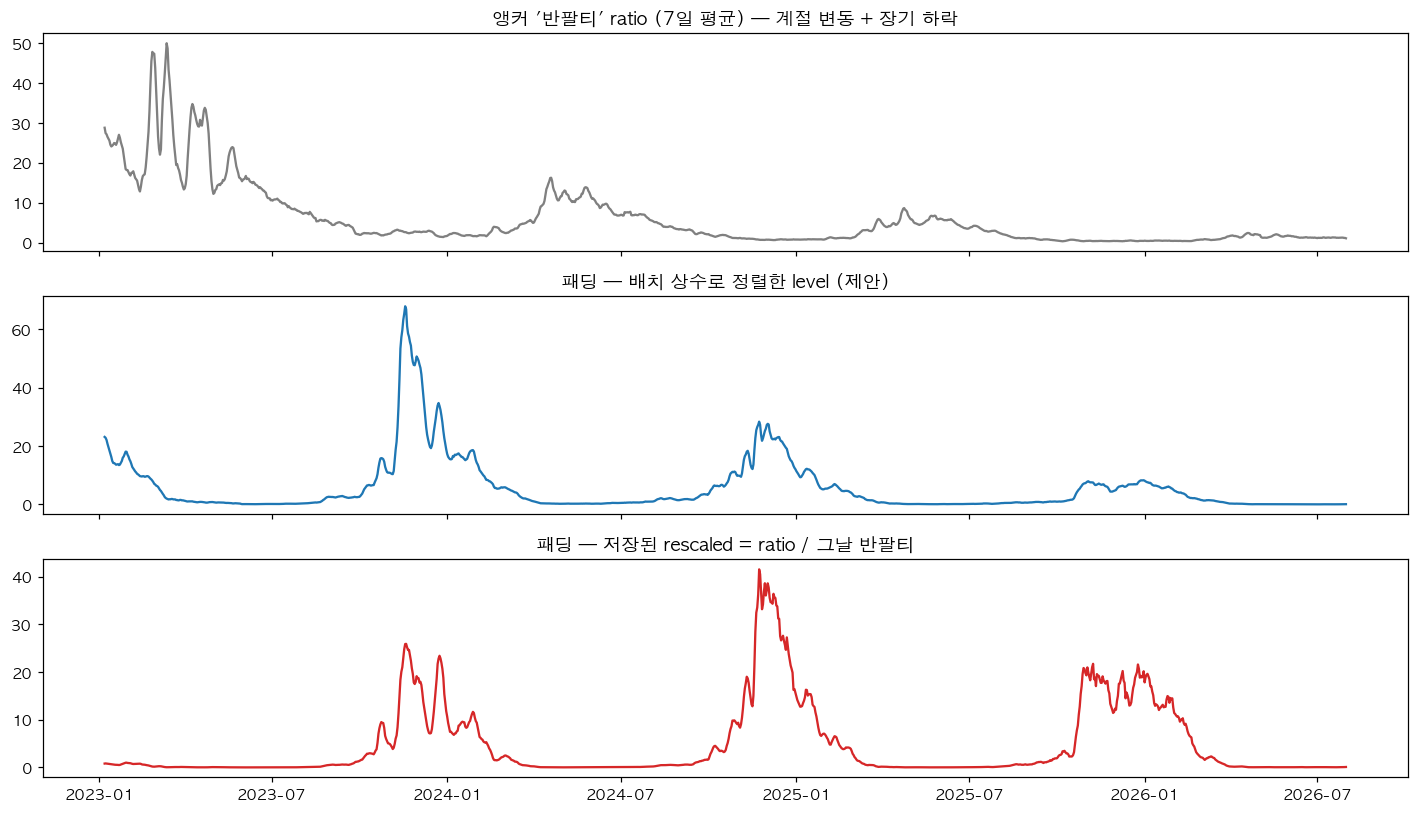

,level,rescaled,반팔티(앵커)
11~12월 평균,,,
2023,36.13,15.56,2.44
2024,19.52,26.07,0.80
2025,6.63,17.42,0.41


In [8]:
def align_batches(df: pd.DataFrame, group_col: str | None) -> pd.DataFrame:
    """배치별 상수 배율로 ratio 를 정렬한다 → 'level' 컬럼. 같은 그룹(cid) 안에서만 비교 가능하다."""
    out = []
    groups = df.groupby(group_col, dropna=False) if group_col else [("전체", df)]
    for _, g in groups:
        anc = g[g["is_anchor"]].pivot_table(index="date", columns="batch_id", values="ratio")
        ref = anc.columns[0]
        factor = (anc[ref].mean() / anc.mean()).rename("factor")
        g = g.merge(factor, left_on="batch_id", right_index=True, how="left")
        g["level"] = g["ratio"] * g["factor"]
        out.append(g)
    res = pd.concat(out)
    return res[~res["is_anchor"] | (res["batch_id"] == res.groupby(group_col or "source")["batch_id"].transform("min"))]

t3a = align_batches(t3, "cid")
t4a = align_batches(t4, None)

pad = t3a[t3a.keyword == "패딩"].set_index("date")
anc = t3[(t3.keyword == "반팔티") & (t3.batch_id == "kw_b01")].set_index("date")["ratio"]

fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True)
axes[0].plot(anc.rolling(7).mean(), color="gray"); axes[0].set_title("앵커 '반팔티' ratio (7일 평균) — 계절 변동 + 장기 하락")
axes[1].plot(pad["level"].rolling(7).mean(), color="tab:blue"); axes[1].set_title("패딩 — 배치 상수로 정렬한 level (제안)")
axes[2].plot(pad["rescaled"].rolling(7).mean(), color="tab:red"); axes[2].set_title("패딩 — 저장된 rescaled = ratio / 그날 반팔티")
plt.tight_layout(); plt.show()

pk = pd.DataFrame({"level": pad["level"], "rescaled": pad["rescaled"], "반팔티(앵커)": anc})
winter_peak = pk[pk.index.month.isin([11, 12])]
winter_peak.groupby(winter_peak.index.year).mean().round(2).rename_axis("11~12월 평균")

**해석** — 세 패널을 같이 봐야 한다.
- **앵커 반팔티 자체가 불안정하다.** 계절 변동(봄 피크)에 더해 **3년간 수십 배 하락**하고, 2023년 2~3월에는 계절과 맞지 않는 스파이크도 있다.
- `level`(가운데)의 패딩 겨울 피크는 해마다 크게 줄어든다(11~12월 평균 36 → 20 → 7). 이 하락이 실제 수요 감소인지는 §2.3에서 확인한다.
- `rescaled`(아래)는 그날 반팔티로 나누므로 공통 하락이 상쇄되어 해마다 비슷해 보인다. 대신 **반팔티만의 움직임(계절·스파이크·반올림 노이즈)이 모든 키워드에 거꾸로 주입된다.**
  반팔티가 가장 낮은 겨울에 분모가 작아지고(최저 0.16), 그 결과 겨울 피크가 과장되고 들쭉날쭉해진다.

즉 `rescaled` 는 "공통 하락 제거"와 "앵커 노이즈 주입"이 섞인 지표다. **배치 정렬은 상수 배율로 하고, 공통 하락은 별도로 다루는 편이 깨끗하다.**

➡️ **이 노트북의 이후 분석은 `level` 을 쓴다**(공통 하락은 §5 분해의 추세 성분이 흡수한다). T1은 앵커(패션의류)가 모든 배치에서 동일해서 `ratio` 를 그대로 쓴다.
T1의 `rescaled` 는 "패션의류 대비 점유율"이라는 다른 지표이므로 필요할 때만 구분해서 쓴다.


### 2.2 T3 희소 키워드: 결측은 0인가, 미관측인가

T3는 클릭이 적은 날의 **행 자체를 누락**시킨다. 키워드별로 1,308일 중 며칠이 있는지, 같은 키워드의 T4(검색어트렌드)와 비교한다.

In [9]:
cid_name = {"50000000": "패션의류", "50000001": "패션잡화", "50000002": "화장품/미용", "50000007": "스포츠/레저"}
cov = (t3a.groupby("keyword").agg(t3_days=("date", "nunique"), cid=("cid", "first"), t3_median=("level", "median"))
       .join(t4a.groupby("keyword").agg(t4_days=("date", "nunique"))))
cov["조회 대분류"] = cov["cid"].map(cid_name)
cov["t3_coverage"] = (cov["t3_days"] / N_DAYS).round(3)
cov.sort_values("t3_days")[["조회 대분류", "t3_days", "t3_coverage", "t4_days", "t3_median"]].head(10)

,조회 대분류,t3_days,t3_coverage,t4_days,t3_median
keyword,,,,,
방수자켓,패션잡화,10,0.008,1308.0,0.001060
선글라스,화장품/미용,10,0.008,1308.0,0.003170
버킷햇,화장품/미용,10,0.008,1308.0,0.003170
히트텍,패션잡화,23,0.018,1308.0,0.001060
레인코트,패션잡화,162,0.124,1308.0,0.001060
기모레깅스,패션잡화,191,0.146,1145.0,0.001060
아쿠아슈즈,스포츠/레저,768,0.587,1308.0,0.008420
린넨팬츠,패션의류,1268,0.969,1219.0,0.161904
롱패딩,패션의류,1282,0.980,1308.0,1.092255


**해석** — 행이 거의 없는 키워드는 **모두 조회한 대분류가 실제 상품 분류와 다르다.**

| 키워드 | T3 일수 | 조회한 대분류 | 실제로 속할 대분류 |
|---|---|---|---|
| 방수자켓·레인코트 | 10·162 | 패션잡화 | 패션의류(또는 스포츠/레저) |
| 히트텍·기모레깅스 | 23·191 | 패션잡화 | 패션의류 |
| 선글라스·버킷햇 | 10·10 | 화장품/미용 | 패션잡화 |
| 아쿠아슈즈 | 768 | 스포츠/레저 | 패션잡화(신발) 가능성 |

같은 키워드의 T4는 1,308일(기모레깅스·린넨팬츠 제외)을 모두 채운다. 즉 **수요가 없는 게 아니라 잘못된 카테고리에서 조회해서 안 잡힌 것**이다.

**처리 기준**
- T3 커버리지 **95% 이상**(롱패딩·야상·목도리·민소매·린넨팬츠 등): 빠진 날은 "지수가 잡히지 않을 만큼 낮은 날"이므로 **0으로 채운다**. 겨울 키워드가 한여름에 빠지는 패턴과 일치한다.
- T3 커버리지 **95% 미만**(7개): cid 불일치라 0으로 채우면 가짜 "수요 0"이 된다. **T3에서는 제외하고, 같은 키워드의 T4(검색어트렌드)로 대체**한다.
  T4는 쇼핑 클릭이 아니라 검색 관심 신호이므로, 대체한 키워드는 이후 표에서 `소스=T4` 로 표시해 구분한다.
- 기모레깅스는 T4도 커버리지가 87.5%라 대체할 수 없어 **분석에서 완전히 제외**한다.


In [10]:
FULL_IDX = wd.index

def to_wide(df_aligned: pd.DataFrame, min_cov: float = 0.95) -> pd.DataFrame:
    w = df_aligned[~df_aligned["is_anchor"]].pivot_table(index="date", columns="keyword", values="level")
    w = w.reindex(FULL_IDX)
    keep = w.columns[w.notna().mean() >= min_cov]
    return w[keep].fillna(0.0)

T3 = to_wide(t3a)                                # 쇼핑 클릭 (구매 직전 신호)
T4 = to_wide(t4a)                                # 검색 (관심 단계 신호)
T1 = t1[t1["category_l2"].notna()].pivot_table(index="date", columns="category_l2", values="ratio").reindex(FULL_IDX)
dropped = sorted(set(t3a.keyword) - set(T3.columns) - {"반팔티", "양말", "립스틱", "등산화"})
subs = [k for k in dropped if k in T4.columns]                     # T3 희소 → T4 로 대체
DEMAND = pd.concat([T3, T4[subs]], axis=1)                         # §6~§7 분석 대상
SOURCE = {k: ("T4" if k in subs else "T3") for k in DEMAND.columns}
print("T3 제외:", dropped)
print("T4 로 대체:", subs, "/ 완전 제외:", sorted(set(dropped) - set(subs)))
print("분석 대상 키워드:", DEMAND.shape[1], "개 (T3", len(T3.columns), "+ T4", len(subs), ") / T1 카테고리:", T1.shape[1], "개")

T3 제외: ['기모레깅스', '레인코트', '방수자켓', '버킷햇', '선글라스', '아쿠아슈즈', '히트텍']
T4 로 대체: ['레인코트', '방수자켓', '버킷햇', '선글라스', '아쿠아슈즈', '히트텍'] / 완전 제외: ['기모레깅스']
분석 대상 키워드: 32 개 (T3 26 + T4 6 ) / T1 카테고리: 14 개


### 2.3 쇼핑인사이트 지수 전체의 구조적 하락

§2.1에서 패딩 `level` 이 해마다 크게 줄었다. 패딩만의 현상인지, 데이터랩 쇼핑 클릭지수 전체의 현상인지 **T1 '패션의류' 대분류**(=카테고리 전체 클릭)로 확인한다.

In [11]:
fashion_l1 = t1[t1["category_l2"].isna()].groupby("date")["ratio"].first().reindex(FULL_IDX)   # T1 앵커 = 패션의류 전체
print("T1 패션의류 대분류 분기 평균:")
print(fashion_l1.groupby(fashion_l1.index.to_period("Q")).mean().round(1).to_string())

peak = lambda s: s[s.index.month.isin([11, 12])].groupby(s.index[s.index.month.isin([11, 12])].year).mean()
cmp_peak = pd.DataFrame({
    "T3 패딩 level": peak(T3["패딩"]),
    "T3 패딩 ÷ 패션의류 전체 (점유율)": peak(T3["패딩"] / fashion_l1),
    "T4 패딩 검색": peak(T4["패딩"]),
})
(cmp_peak / cmp_peak.iloc[0]).round(2).rename_axis("11~12월 평균, 2023=1")

T1 패션의류 대분류 분기 평균:
date
2023Q1    66.7
2023Q2    47.9
2023Q3    36.6
2023Q4    50.4
2024Q1    38.4
2024Q2    37.1
2024Q3    29.4
2024Q4    37.5
2025Q1    26.9
2025Q2    26.0
2025Q3    16.6
2025Q4    18.4
2026Q1    12.9
2026Q2    11.3
2026Q3    10.0
Freq: Q-DEC


,T3 패딩 level,T3 패딩 ÷ 패션의류 전체 (점유율),T4 패딩 검색
"11~12월 평균, 2023=1",,,
2023,1.00,1.00,1.00
2024,0.54,0.77,0.80
2025,0.18,0.54,0.57


**해석**
- **패션의류 카테고리 전체 클릭지수가 2023년 1분기 대비 2026년 3분기에 약 1/6로 떨어졌다.** 패딩만이 아니라 쇼핑인사이트 클릭지수 전체가 구조적으로 하락했다.
  (원인은 이 데이터로 알 수 없다. 네이버 쇼핑 서비스 구조 변화로 데이터랩 집계 대상이 달라졌을 가능성이 있다 — 확인 필요.)
- 패딩을 **패션의류 전체 대비 점유율**로 바꾸면 2025년 겨울 피크는 2023년의 약 0.5배다. **T4 검색어트렌드의 하락 폭(약 0.6배)과 비슷해진다.**
  `level` 의 하락(약 0.2배) 중 대부분은 플랫폼 전체 하락이고, 패딩 고유의 관심 감소는 그보다 작다는 뜻이다.

➡️ **시사점**
1. 연도를 넘는 비교(예: "2023년 겨울보다 2025년 겨울 패딩 수요가 줄었다")는 `level` 로 하면 안 된다. **T4로 교차 확인**해야 한다(패션의류 키워드는 위처럼 T1 점유율로도 확인 가능).
2. W5 타깃("7일 이동평균 대비 상위 20%")은 짧은 창의 상대 비교라 이 하락에 비교적 강하다. 반면 **3년 전체 기준의 임계값이나 정규화는 하락에 취약하다.**
3. §4에서 볼 "쇼핑 트래픽 공통 요인"도 점유율로 바꾸면 함께 통제된다.

**처리 기준** — 분석 지표는 추가 수집 없이 **배치 상수로 정렬한 `level`** 을 쓴다. 공통 하락은 §5 분해의 추세 성분이 흡수하고, 연도 간 비교가 필요할 때만 T4로 교차 확인한다.


---
## 3. 계절성 한눈에 보기

§2.3의 장기 하락 때문에 그냥 월평균을 내면 **데이터가 한 해 더 있는 1~7월(2026년 포함)이 왜곡된다.**
그래서 각 시계열을 **365일 중심 이동평균으로 나눈 계절 지수**(ratio-to-moving-average)로 바꾼 뒤, 키워드별 월평균을 z-score화해 "언제 뜨는가"의 모양만 비교한다.

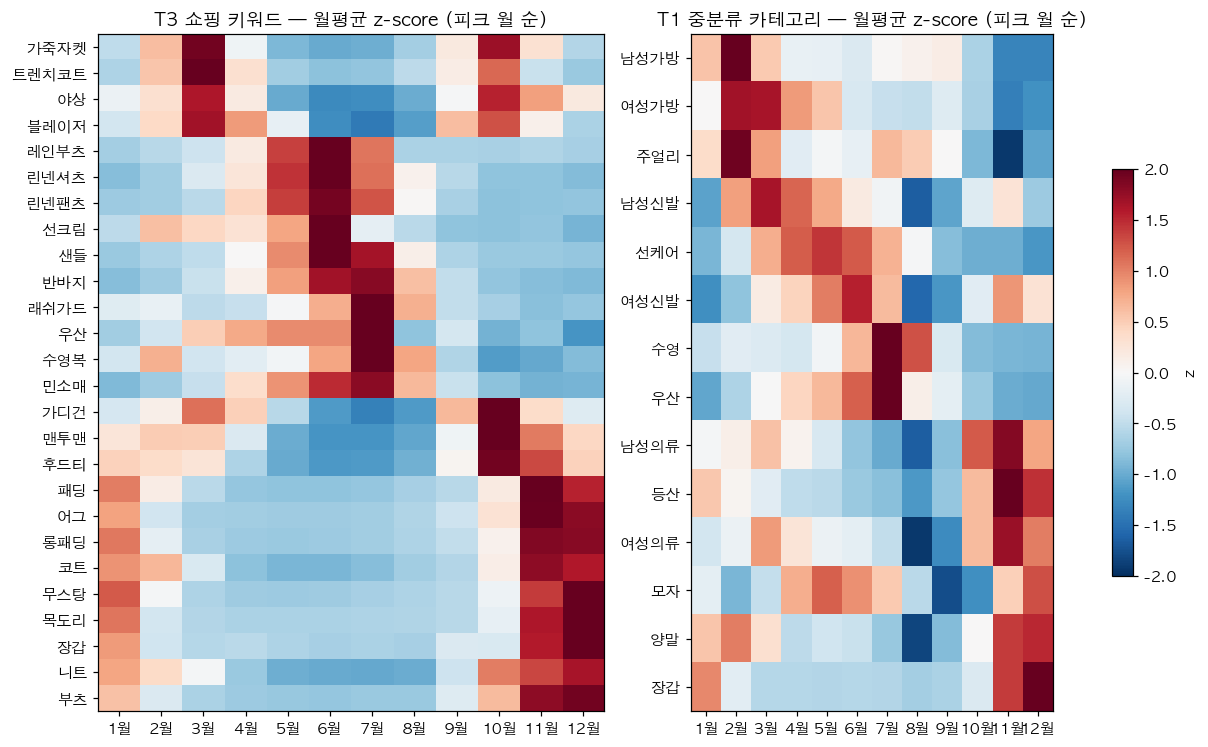

피크월 / 최저월 배수 (상위 8):
keyword
목도리      335.0
롱패딩      115.3
패딩        93.4
무스탕       80.3
트렌치코트     58.5
맨투맨       54.8
장갑        52.7
코트        49.5


In [12]:
def seasonal_index(wide: pd.DataFrame) -> pd.DataFrame:
    """장기 추세를 나눠 없앤 계절 지수. 1보다 크면 그 시점이 연평균보다 높다."""
    return wide / wide.rolling(365, center=True, min_periods=180).mean()

def monthly_z(wide: pd.DataFrame) -> pd.DataFrame:
    mm = seasonal_index(wide).groupby(wide.index.month).mean()
    z = (mm - mm.mean()) / mm.std()
    return z.T.loc[z.T.idxmax(axis=1).sort_values().index]   # 피크 월 순 정렬

fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [1.4, 1]})
for ax, (title, wide) in zip(axes, [("T3 쇼핑 키워드", T3), ("T1 중분류 카테고리", T1)]):
    z = monthly_z(wide)
    im = ax.imshow(z.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_xticks(range(12), [f"{m}월" for m in range(1, 13)])
    ax.set_yticks(range(len(z)), z.index)
    ax.set_title(f"{title} — 월평균 z-score (피크 월 순)")
fig.colorbar(im, ax=axes, shrink=0.6, label="z")
plt.show()

si = seasonal_index(T3).groupby(T3.index.month).mean()
amp = si.max() / si.min().clip(lower=1e-3)
print("피크월 / 최저월 배수 (상위 8):"); print(amp.sort_values(ascending=False).head(8).round(1).to_string())

**해석**
- **T3 키워드는 네 덩어리로 갈린다.** 환절기형(가죽자켓·트렌치코트·야상·블레이저: **3월·10월 쌍봉**), 여름형(레인부츠·린넨·샌들·반바지·래쉬가드: 6~7월),
  가을 상의형(가디건·맨투맨·후드티: 10월), 겨울형(패딩·롱패딩·무스탕·목도리·장갑·부츠: 11~12월). `categories.yaml` 의 그룹 가설과 대체로 맞는다.
- **추세를 빼지 않으면 결론이 틀어진다.** 같은 히트맵을 원래 월평균으로 그리면 우산·후드티의 피크가 1월로 나온다. 2023년 초의 높은 지수(§2.3 하락 이전)가 1월 평균을 끌어올리기 때문이다.
  추세 제거 후 우산은 **7월(장마)** 에 정확히 피크를 찍는다. T1 '우산' 카테고리도 7월 피크라 **두 소스가 서로 일치**한다.
- **T1 중분류는 날씨보다 달력을 따른다.** 여성가방·남성가방·주얼리는 **2월**(졸업·입학·밸런타인 선물 수요), 신발은 3~6월, 의류는 11월에 피크다.
  중분류는 여러 품목이 섞여 날씨 신호가 희석된다. datasets.md의 "진짜 신호는 T3 키워드에 있다"는 판단을 데이터가 뒷받침한다.
- 계절지수 기준 **피크월/최저월 배수가 목도리 335배, 롱패딩 115배**다. 원 시계열에서는 계절이 날씨 효과를 압도한다. §5에서 계절을 먼저 걷어내야 하는 이유다.

🤔 **직접 확인** — 환절기형 키워드의 봄 피크와 가을 피크 중 어느 쪽이 더 큰가? 그 차이를 일교차로 설명할 수 있는가, 아니면 "신학기·가을 신상" 같은 마케팅 요인인가?

---
## 4. 가짜 상관 실습: 원 시계열 상관 vs 차분 상관

CLAUDE.md §7 원칙 "원 시계열끼리 상관계수를 내지 않는다"를 직접 확인한다.
**서로 인과가 없는 계절 반대 키워드 쌍**(패딩 vs 린넨셔츠, 코트 vs 반바지)과 **인과가 있을 법한 쌍**(패딩 vs 최저기온)을 비교한다.
마지막 두 열은 쌍의 앞(A)·뒤(B) 키워드 차분과 **T1 '패션의류' 전체 지수 차분**의 상관이다(쇼핑 트래픽 공통 요인).

In [13]:
fashion_total = np.log(fashion_l1)        # §2.3 의 T1 패션의류 전체 지수
pairs = {
    "패딩 vs 최저기온": ("패딩", None),
    "패딩 vs 린넨셔츠": ("패딩", "린넨셔츠"),
    "코트 vs 반바지": ("코트", "반바지"),
}
rows = []
for name, (a, b) in pairs.items():
    la = np.log1p(T3[a])
    lb = wd["t_min"] if b is None else np.log1p(T3[b])
    rows.append({"쌍": name,
                 "원 시계열 r": la.corr(lb),
                 "1차 차분 r": la.diff().corr(lb.diff()),
                 "A 차분 × 패션의류 전체 차분": la.diff().corr(fashion_total.diff()),
                 "B 차분 × 패션의류 전체 차분": np.nan if b is None else lb.diff().corr(fashion_total.diff())})
pd.DataFrame(rows).set_index("쌍").round(2)

,원 시계열 r,1차 차분 r,A 차분 × 패션의류 전체 차분,B 차분 × 패션의류 전체 차분
쌍,,,,
패딩 vs 최저기온,-0.68,-0.23,0.45,NaN
패딩 vs 린넨셔츠,-0.55,0.17,0.45,0.46
코트 vs 반바지,-0.37,0.18,0.46,0.54


**해석**
- 계절이 반대인 **패딩–린넨셔츠(-0.55)**, **코트–반바지(-0.37)** 는 원 시계열에서 뚜렷한 음의 상관을 보인다. 서로 영향을 주는 관계가 아니라 **둘 다 계절을 따라 반대로 움직일 뿐**이다.
- 1차 차분을 하면 부호가 **양(+0.17·+0.18)으로 뒤집힌다.** 계절 반대 품목인데도 "같은 날 같이 오르고 같이 내린다"는 뜻이다.
  원인은 마지막 두 열에 있다. 각 키워드의 차분이 **패션의류 전체 지수 차분과 +0.45~0.54의 상관**을 보인다. 요일, 할인 행사, 플랫폼 트래픽처럼 모든 키워드를 함께 움직이는 **공통 요인**이다.
- 패딩–최저기온도 원 시계열 -0.68 중 상당 부분은 "겨울이라서"다. 차분 후 -0.23으로 줄어든다.

➡️ 교훈: **차분은 계절을 지우지만 공통 요인은 남긴다.** 날씨 효과를 보려면 ① 계절 제거 ② 요일 제거 ③ 공통 쇼핑 트래픽 통제가 모두 필요하다.
이 노트북에서는 ①②까지 다룬다. ③은 추가 수집 없이 모든 키워드에 적용할 방법이 없어 한계로 남긴다(패션의류 키워드만 §2.3의 T1 점유율로 보조 확인 가능).

---
## 5. 계절 분해: 수요 = 추세 + 연 계절 + 주 계절 + 잔차

**설계 결정**
- **로그 변환 후 분해**: 검색지수는 겨울에 커지면 변동폭도 함께 커지는 **곱셈형** 구조라, 로그를 취해 덧셈형으로 바꾼다.
- **MSTL(periods=(7, 365))**: 일별 데이터에는 주간(7)과 연간(365) 계절이 모두 있다. 한 개만 쓰면 다른 하나가 잔차에 남는다.
- **`robust=False`**: 아래 §5.1에서 보듯 3.6년 데이터에서 `robust=True` 는 계절 성분이 특정 연도 값을 통째로 흡수한다.

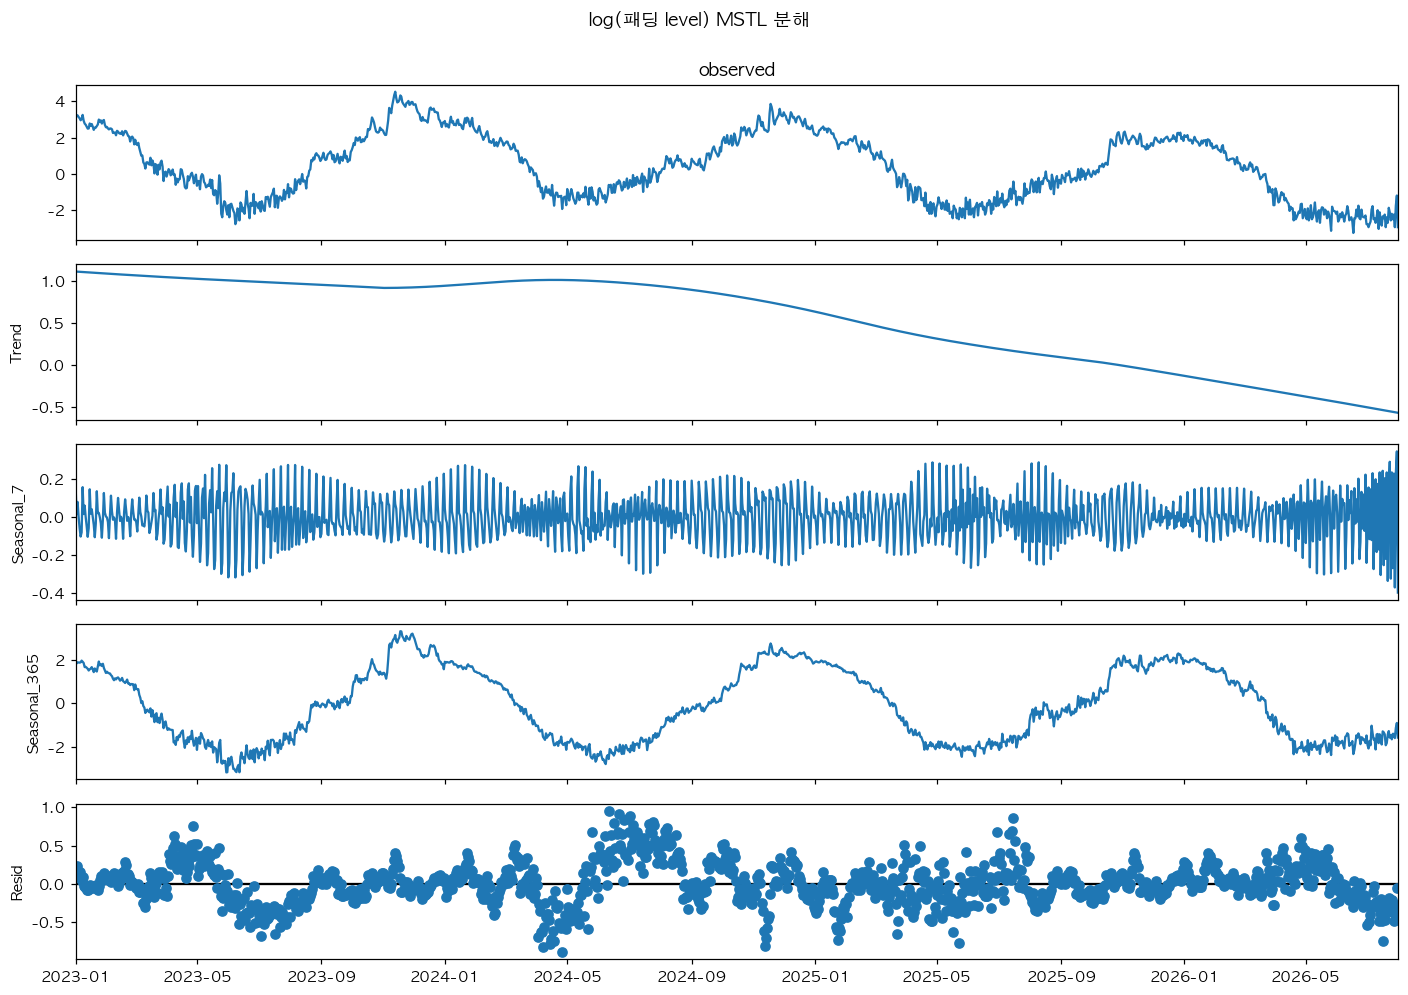

,분산 비중(근사)
trend,0.089
연 계절,0.883
주 계절,0.004
잔차,0.024


In [14]:
def log_level(s: pd.Series) -> pd.Series:
    eps = max(s[s > 0].quantile(0.01), 1e-3)          # 0 이 있으면 log 가 터지므로 하위 1% 값을 바닥으로
    return np.log(s + eps)

def decompose_demand(s: pd.Series):
    return MSTL(log_level(s), periods=(7, 365)).fit()

res_pad = decompose_demand(T3["패딩"])
fig = res_pad.plot(); fig.set_size_inches(13, 9); fig.suptitle("log(패딩 level) MSTL 분해", y=1.0)
plt.tight_layout(); plt.show()

var_share = pd.Series({
    "trend": res_pad.trend.var(), "연 계절": res_pad.seasonal["seasonal_365"].var(),
    "주 계절": res_pad.seasonal["seasonal_7"].var(), "잔차": res_pad.resid.var(),
})
(var_share / var_share.sum()).round(3).to_frame("분산 비중(근사)")

**해석** — 로그 패딩 수요 변동의 **88%를 연 계절 성분이, 9%를 추세(§2.3의 장기 하락)가 설명한다.** 주 계절은 0.4%로 작다.
날씨 효과가 들어 있는 **잔차는 전체 변동의 2.4%에 불과하다.**
원 시계열 차트만 보고 날씨 효과를 말하면 안 되는 이유다.
(성분끼리 완전히 독립이 아니어서 분산 비중의 합이 정확히 분해되지는 않는다. 크기 감을 잡는 용도로만 쓴다.)

### 5.1 3.6년 데이터에서 365일 주기를 분해할 때의 함정

1,308일은 연 주기 **3.6바퀴**다. STL은 "매년 같은 날짜" 값들(=날짜별 3~4개)로 계절 성분을 추정한다.
표본이 이렇게 적으면 **계절 성분이 그해 날씨까지 흡수**할 수 있다. 기온으로 직접 확인한다.

In [15]:
def fourier_baseline(y: pd.Series, K: int = 3, weekday: bool = False) -> pd.Series:
    """평년값 = 선형 추세 + 연 주기 사인·코사인 K쌍 (+ 요일 더미). 모든 연도가 같은 계절 곡선을 공유한다."""
    idx = y.index
    doy = 2 * np.pi * idx.dayofyear.values / 365.25
    cols = [np.ones(len(idx)), np.arange(len(idx)) / 365.25]
    cols += [f(k * doy) for k in range(1, K + 1) for f in (np.sin, np.cos)]
    if weekday:
        cols += [(idx.dayofweek == d).astype(float) for d in range(1, 7)]
    X = np.column_stack(cols)
    ok = y.notna().values
    beta = np.linalg.lstsq(X[ok], y.values[ok], rcond=None)[0]
    return pd.Series(X @ beta, index=idx)

stl_rob = STL(wd["t_min"], period=365, robust=True).fit()
clim = fourier_baseline(wd["t_min"], K=3)
demo = pd.DataFrame({
    "t_min(관측)": wd["t_min"],
    "STL robust 계절+추세": stl_rob.seasonal + stl_rob.trend,
    "STL robust 편차": stl_rob.resid,
    "푸리에 평년값": clim,
    "푸리에 편차": wd["t_min"] - clim,
    "robust 가중치": stl_rob.weights,
}).round(2)
print("robust 가중치가 0인 날의 비율:", round((stl_rob.weights < 1e-6).mean(), 3))
pd.concat([demo.loc["2023-12-06":"2023-12-10"], demo.loc["2024-12-06":"2024-12-10"]])

robust 가중치가 0인 날의 비율: 0.441


,t_min(관측),STL robust 계절+추세,STL robust 편차,푸리에 평년값,푸리에 편차,robust 가중치
date,,,,,,
2023-12-06,3.9,3.90,0.00,-0.81,4.71,0.92
2023-12-07,0.8,0.80,0.00,-1.03,1.83,0.92
2023-12-08,5.1,5.10,0.00,-1.24,6.34,0.92
2023-12-09,11.7,11.70,0.00,-1.45,13.15,0.92
2023-12-10,6.7,6.70,0.00,-1.66,8.36,0.92
2024-12-06,-0.4,-0.55,0.15,-1.07,0.67,0.00
2024-12-07,-2.5,4.30,-6.80,-1.28,-1.22,0.00
2024-12-08,-3.9,6.30,-10.20,-1.49,-2.41,0.00
2024-12-09,-3.8,2.20,-6.00,-1.70,-2.10,0.00


**해석** — 2023-12-09는 최저기온 11.7℃로 **평년보다 13℃ 이상 따뜻한 이상고온**이었다. 그런데 STL robust의 편차는 **정확히 0.0**이다.
계절+추세 성분이 관측값을 그대로 따라가서 이상고온을 "계절"로 흡수했다. 원인은 마지막 열에 있다. robust 반복에서 **전체 날짜의 약 44%가 가중치 0으로 버려진다.**
2024-12 구간은 가중치 0(버려짐)이라 편차가 크게 남고, 2023-12 구간은 가중치 0.92로 남아 있다. 같은 날짜의 표본이 3~4개뿐인데 그중 일부가 버려지면, **남은 연도에 계절 곡선이 정확히 맞춰져 편차가 0이 된다.**
**이런 편차로 날씨 효과를 찾으면 가장 극단적인 날씨가 지워진다.**

**결정** — 기온의 평년값은 **푸리에 평년값**(모든 연도가 같은 매끈한 계절 곡선을 공유)으로 만든다.
"평년 대비 몇 도 추웠나"라는 설명도 이쪽이 직관적이다.

In [16]:
wx = pd.DataFrame({
    "t_min_anom": wd["t_min"] - fourier_baseline(wd["t_min"]),
    "t_max_anom": wd["t_max"] - fourier_baseline(wd["t_max"]),
    "dtr_anom": wd["dtr"] - fourier_baseline(wd["dtr"]),
    "dt_min": wd["dt_min"],
    "log_precip": np.log1p(wd["precip_mm"]),
})

# 수요 쪽도 같은 문제가 있는지: MSTL 잔차 vs 푸리에(K=6)+요일 기준선 잔차
def fourier_resid(s: pd.Series) -> pd.Series:
    y = log_level(s)
    return y - fourier_baseline(y, K=6, weekday=True)

mm = seasonal_index(DEMAND).groupby(DEMAND.index.month).mean()                             # §3 의 추세 제거 계절 지수
ACTIVE = {k: [m for m in range(1, 13) if mm.loc[m, k] >= 0.4 * mm[k].max()] for k in DEMAND}  # 성수기: 피크월 계절지수의 40% 이상

sens = []
for k in ["패딩", "롱패딩", "장갑", "목도리", "코트", "반바지"]:
    msk = FULL_IDX.month.isin(ACTIVE[k])
    r_m, r_f = decompose_demand(T3[k]).resid, fourier_resid(T3[k])
    sens.append({"키워드": k, "성수기(월)": ACTIVE[k],
                 "MSTL 잔차 × t_min편차": r_m[msk].corr(wx["t_min_anom"][msk]),
                 "푸리에 잔차 × t_min편차": r_f[msk].corr(wx["t_min_anom"][msk]),
                 "MSTL 잔차 lag7 ACF": r_m.autocorr(7), "푸리에 잔차 lag7 ACF": r_f.autocorr(7)})
pd.DataFrame(sens).set_index("키워드").round(2)

,성수기(월),MSTL 잔차 × t_min편차,푸리에 잔차 × t_min편차,MSTL 잔차 lag7 ACF,푸리에 잔차 lag7 ACF
키워드,,,,,
패딩,"[1, 11, 12]",-0.38,-0.52,0.50,0.57
롱패딩,"[1, 11, 12]",-0.46,-0.74,0.21,0.49
장갑,"[1, 11, 12]",-0.38,-0.61,0.35,0.34
목도리,"[1, 11, 12]",-0.27,-0.46,0.23,0.25
코트,"[1, 2, 10, 11, 12]",-0.12,-0.08,0.38,0.58
반바지,"[4, 5, 6, 7, 8]",0.36,0.42,0.43,0.46


**해석** — **기준선 선택에 따라 효과 크기가 크게 달라진다.** 같은 롱패딩인데 MSTL 잔차로 보면 상관이 약하고, 푸리에 기준선으로 보면 훨씬 강하다.
(롱패딩 -0.46 vs -0.74, 장갑 -0.38 vs -0.61). MSTL의 365일 계절 성분이 날씨 반응 일부를 흡수하기 때문이다(§5.1과 같은 이유).
반대로 푸리에 기준선은 매년 계절 모양이 같다고 가정하고 추세도 직선이라, **연도별 수준 차이(§2.3의 비선형 하락 포함)까지 잔차로 넘길 위험**이 있다.
푸리에 잔차의 lag7 ACF가 대체로 더 높게 남는 것이 그 흔적이다(롱패딩 0.21 → 0.49, 코트 0.38 → 0.58).

➡️ **진짜 효과는 두 값 사이 어딘가에 있다.**

**처리 기준** — 본 분석의 계절 기준선은 **MSTL**(보수적인 쪽)로 한다. 푸리에 기준선 결과는 **참고용 상한값**으로만 두고, 효과 크기를 말할 때 "MSTL 기준"임을 명시한다.


---
## 6. 시차 상관 (CCF): 날씨는 수요를 며칠 앞서는가

`corr(수요잔차[t], 날씨[t - k])`. **k > 0 이면 날씨가 k일 먼저 오고 수요가 뒤따른다.**

**설계 결정 2가지**
1. **성수기로 한정한다.** 비수기(여름의 패딩)는 지수가 작아 로그 잔차가 노이즈로 가득하다. 실제로 전 기간 패딩 잔차 상위 10일 중 9일이 2024년 6~7월이었다.
2. **차분 CCF를 함께 본다.** 수요 잔차와 기온 편차가 둘 다 며칠씩 지속되기 때문에(자기상관), 원래 CCF는 폭이 넓게 퍼지고 점선(±1.96/√n) 유의 기준도 너무 관대해진다.
   양쪽을 차분한 CCF가 "며칠째에 반응하나"를 더 정확히 보여준다.

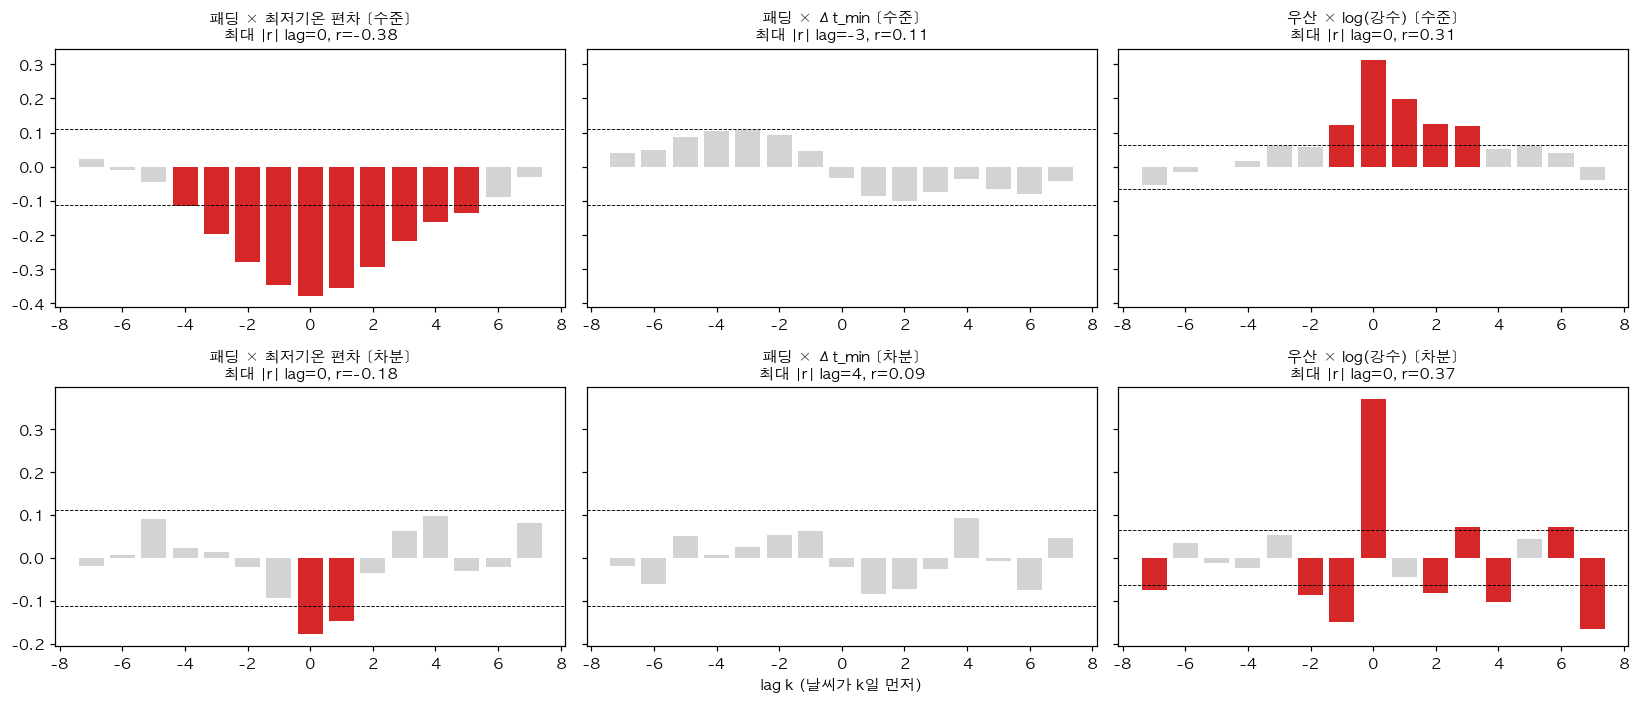

In [17]:
def ccf(y: pd.Series, x: pd.Series, max_lag: int = 7) -> pd.Series:
    return pd.Series({k: y.corr(x.shift(k)) for k in range(-max_lag, max_lag + 1)})

res_umb = decompose_demand(T3["우산"])
cases = [("패딩 × 최저기온 편차", res_pad.resid, wx["t_min_anom"], ACTIVE["패딩"]),
         ("패딩 × Δt_min", res_pad.resid, wx["dt_min"], ACTIVE["패딩"]),
         ("우산 × log(강수)", res_umb.resid, wx["log_precip"], ACTIVE["우산"])]

fig, axes = plt.subplots(2, 3, figsize=(15, 6.5), sharey="row")
for j, (title, y, x, months) in enumerate(cases):
    msk = pd.Series(FULL_IDX.month.isin(months), index=FULL_IDX)
    for i, (label, yy, xx) in enumerate([("수준", y, x), ("차분", y.diff(), x.diff())]):
        c = ccf(yy.where(msk), xx)
        ci = 1.96 / np.sqrt(msk.sum())
        ax = axes[i, j]
        ax.bar(c.index, c.values, color=["tab:red" if abs(v) > ci else "lightgray" for v in c.values])
        ax.axhline(ci, ls="--", c="k", lw=0.6); ax.axhline(-ci, ls="--", c="k", lw=0.6)
        best = c.abs().idxmax()
        ax.set_title(f"{title} [{label}]\n최대 |r| lag={best}, r={c[best]:.2f}", fontsize=10)
axes[1, 1].set_xlabel("lag k (날씨가 k일 먼저)")
plt.tight_layout(); plt.show()

**해석**
- **패딩 × 최저기온 편차**: 성수기 수준 CCF는 lag 0에서 가장 강하다(아래 그림 제목의 r). 그런데 **lag -4~+5에 걸쳐 거의 대칭으로 퍼진다.**
  대칭으로 퍼지는 것은 수요가 늦게 반응하거나 미리 반응해서가 아니라 **추위가 며칠씩 지속되기 때문**이다(기온 편차의 lag-1 자기상관이 높다).
  차분 CCF에서는 신호가 **lag 0·1 두 칸에만 남는다.** 결론은 "추워진 당일과 다음 날 반응한다"이다. 예보를 보고 미리 사는 선행 반응은 이 방법으로는 보이지 않는다.
- **패딩 × Δt_min**: 수준·차분 모두 **유의선 안쪽**이다. 전일 대비 급강하 자체는 패딩 수요를 추가로 설명하지 못한다(§7에서 전체 키워드로 확인).
- **우산 × 강수**: 차분 CCF는 **lag 0에서만 크게 튄다.** 양옆의 음수 막대는 차분이 만드는 기계적 효과다(스파이크를 차분하면 앞뒤가 음수가 된다).
  우산은 **비가 온 그날 사는 즉시 반응형**이다.

🤔 **직접 확인** — 같은 CCF를 T4(검색어트렌드) 패딩으로 그려보라. T4 반응이 T3보다 먼저 오면 "관심 → 구매" 시차의 증거가 된다(Q4 대체 후보).

---
## 7. 핵심 가설 스크리닝: 기온 편차 vs Δt vs 일교차

T3 키워드마다 **성수기 안에서** MSTL 잔차와 날씨 변수의 lag 0 상관을 구한다. 가설("절대 기온보다 Δt·일교차가 더 잘 설명한다")이 맞다면
`dt_min`·`dtr_anom` 열이 `t_min_anom`·`t_max_anom` 열보다 커야 한다. 마지막 열은 **"평년보다 1℃ 추울 때 수요 변화율(%)"** 이다.

> ⚠️ 키워드 × 변수 조합을 여러 개 비교하므로 다중 비교 문제가 있다. **순위를 보는 탐색용**이며 최종 결론은 W4 이벤트 분석에서 낸다.

In [18]:
resid = pd.DataFrame({k: decompose_demand(DEMAND[k]).resid for k in DEMAND.columns})
group_of = {kw: g for g, spec in CATS["weather_sensitive"].items() for kw in spec["items"]}
VARS = ["t_min_anom", "t_max_anom", "dtr_anom", "dt_min", "log_precip"]

rows = {}
for k in resid:
    msk = FULL_IDX.month.isin(ACTIVE[k])
    y, X = resid[k][msk], wx[msk]
    row = {"그룹": group_of.get(k), "소스": SOURCE[k], "성수기": ",".join(map(str, ACTIVE[k])), "n": int(msk.sum())}
    row.update({v: y.corr(X[v]) for v in VARS})
    slope = np.polyfit(X["t_min_anom"], y, 1)[0]                     # 로그 잔차 ~ 기온 편차
    row["1℃ 추울 때 %"] = (np.exp(-slope) - 1) * 100
    rows[k] = row
screen = pd.DataFrame(rows).T
screen[VARS + ["1℃ 추울 때 %"]] = screen[VARS + ["1℃ 추울 때 %"]].astype(float).round(2)
screen["최강 변수"] = screen[VARS].abs().idxmax(axis=1)
# 기온보다 강수·일교차가 더 강한 품목(우산류)은 기온 기울기가 강수의 대리 효과라 해석하지 않는다
screen.loc[screen["최강 변수"].isin(["log_precip", "dtr_anom"]) | (screen["그룹"] == "rain"), "1℃ 추울 때 %"] = np.nan
screen.sort_values(["그룹", "t_min_anom"])

,그룹,소스,성수기,n,t_min_anom,t_max_anom,dtr_anom,dt_min,log_precip,1℃ 추울 때 %,최강 변수
수영복,beach,T3,"1,2,3,4,5,6,7,8,9",1032,-0.11,-0.08,-0.00,0.02,0.00,0.57,t_min_anom
아쿠아슈즈,beach,T4,"6,7,8",337,0.30,0.32,0.18,0.02,-0.15,-0.85,t_max_anom
래쉬가드,beach,T3,"6,7,8",337,0.32,0.22,0.05,-0.01,-0.12,-2.21,t_min_anom
린넨팬츠,bottom_summer,T3,"4,5,6,7",488,0.30,0.20,0.00,0.03,-0.03,-2.59,t_min_anom
반바지,bottom_summer,T3,"4,5,6,7,8",581,0.36,0.26,0.03,-0.05,-0.04,-2.92,t_min_anom
히트텍,cold_acc,T4,"1,11,12",307,-0.45,-0.43,0.04,-0.06,-0.06,2.44,t_min_anom
장갑,cold_acc,T3,"1,11,12",307,-0.38,-0.36,0.04,-0.03,0.01,3.12,t_min_anom
목도리,cold_acc,T3,"1,11,12",307,-0.27,-0.21,0.11,0.01,-0.03,2.45,t_min_anom
야상,outerwear_transition,T3,"1,2,3,4,9,10,11,12",847,-0.03,-0.03,0.01,0.02,0.01,0.18,t_min_anom
블레이저,outerwear_transition,T3,"1,2,3,4,5,9,10,11",878,0.04,0.06,0.04,-0.01,-0.03,-0.25,t_max_anom


In [19]:
summary = screen.groupby("최강 변수").agg(키워드수=("n", "size"))
summary["평균 |r| (해당 변수, 전체 키워드)"] = [screen[v].abs().mean().round(3) for v in summary.index]
summary.loc["dt_min", ["키워드수", "평균 |r| (해당 변수, 전체 키워드)"]] = [
    (screen["최강 변수"] == "dt_min").sum(), screen["dt_min"].abs().mean().round(3)]
summary.sort_values("키워드수", ascending=False)

,키워드수,"평균 |r| (해당 변수, 전체 키워드)"
최강 변수,,
t_min_anom,17.0,0.183
t_max_anom,10.0,0.203
log_precip,3.0,0.085
dtr_anom,2.0,0.085
dt_min,0.0,0.024


**해석**
- **Δt(전일 대비 최저기온 변화)는 어떤 키워드에서도 최강 변수가 아니다.** 성수기 상관의 절댓값이 전부 0.1 미만이다.
  "전날보다 추워졌다"는 사실 자체보다 **"평년보다 몇 도 추운가(기온 편차)"** 가 수요를 설명한다. **핵심 가설의 Δt 부분은 일 단위 상관으로는 지지되지 않는다.**
- **겨울 아우터·방한 소품(롱패딩·패딩·장갑·목도리·무스탕)이 날씨에 가장 민감하다.** 위 표의 마지막 열을 보면 평년보다 1℃ 추울 때 수요가 몇 % 느는지 알 수 있다.
  1℃당 롱패딩 +3.3%, 장갑 +3.1%, 목도리 +2.5%, 패딩 +1.7%다. 리포트에서는 이 숫자로 말한다. 예: **"성수기 최저기온이 평년보다 5℃ 낮으면 장갑 클릭 약 +17%"**.
  단 §5.1에서 봤듯 MSTL 기준선은 보수적이다. 푸리에 기준선이면 상관이 1.3~1.6배 커지므로 **효과 크기는 기준선을 명시하고 범위로 말한다.**
- 여름 품목은 부호가 반대다(반바지·린넨팬츠·래쉬가드는 평년보다 1℃ 더울 때 +2.2~2.9%). **신호가 있는 키워드는 모두 방향이 도메인 직관과 맞는다.**
- **코트는 같은 겨울 아우터인데 기온 민감도가 약하다.** 코트는 날씨보다 스타일·출근복 수요에 가까운 품목이라는 해석이 가능하다. "모든 겨울옷이 추위에 반응하지는 않는다"는 것 자체가 발견이다.
- **우산·레인부츠는 `dtr_anom`(일교차 편차)과도 음의 상관이 강하다.** 비 오는 날은 구름 때문에 일교차가 작다. 일교차가 수요를 움직인다기보다 **강수의 대리 변수**일 가능성이 높다. 교란 변수 사례로 리포트에 쓸 만하다.
- **T4로 대체한 키워드도 같은 방향이다.** 히트텍은 기온 편차와 -0.45로 방한 소품 중 가장 강하고, 레인코트·방수자켓은 강수가 최강 변수(0.33~0.38)로 우산과 같은 패턴이다.
  아쿠아슈즈는 여름 물놀이 품목답게 평년보다 더울 때 오른다. 단 T4는 검색 관심 신호라 **T3 키워드와 상관 크기를 직접 비교하지 않는다.**
- 환절기 키워드는 약하다. 트렌치코트·가죽자켓은 +0.2 수준(제철 안에서는 평년보다 따뜻한 날 더 찾는다)이고, 야상·블레이저·가디건은 거의 0이다.
  **환절기 수요는 날씨보다 달력(시즌 전환 시점)이 결정한다**는 가설로 이어진다. W4 이벤트 윈도우에서 "환절기 D0" 전후를 확인한다.
- 수영복은 성수기가 1~9월로 넓게 잡혀 신호가 흐려졌다. 실내 수영 수요가 섞인 키워드일 수 있다. 래쉬가드(6~8월)가 여름 물놀이 신호로 더 깨끗하다.

🤔 **직접 확인** — Δt가 약하게 나온 이유가 "일 단위라서"일 수 있다. 3일 누적 변화(`t_min.diff(3)`)나 "급강하 이벤트 전후 윈도우"로 보면 달라지는가? (W4의 급강하 플래그와 연결)

---
## 8. 이벤트 정의 점검: 한파 임계값을 특보 이력으로 정하기

원안의 한파 정의(`t_min ≤ -12℃` 2일 이상 지속 첫날)가 서울 단일 관측소에서 충분한 사례를 만드는지 확인하고, 실제 한파특보와 대조해 임계값을 정한다. 목표는 연 2~5회다.

**특보 데이터 처리 규칙 (이 노트북에서 정한 것)**
- `lvl=1` 은 문서상 "주의"지만 **실제 데이터에서는 `예비`(예비특보)** 다 → 제외하고 주의보(2)·경보(3)만 쓴다.
- 발표(`cmd=1`)~해제(`cmd=3`)를 권역별로 짝지어 발효 구간을 만들고, **4개 권역 중 하나라도 발효 중이면 "서울 특보일"**(any)로 본다.
- `wrn_name` 에 문서의 6종(C/H/R/S/D/W) 외에 `열대야`·`태풍` 도 있다. 이번 분석에서는 쓰지 않는다.

In [20]:
warn = pd.concat([pd.read_csv(f, parse_dates=["tm_fc", "tm_ef"]) for f in sorted((RAW / "kma_warning").glob("*.csv"))])
warn = warn[warn["lvl"].isin([2, 3])].sort_values("tm_ef")

def warning_days(warn: pd.DataFrame, wrn: str, max_days: int = 10) -> pd.Series:
    """권역별 발표~해제 구간을 날짜로 펼쳐 any 로 합친다. 해제 행이 없으면 max_days 에서 끊는다."""
    days = pd.Series(False, index=FULL_IDX)
    for _, g in warn[warn["wrn"] == wrn].groupby("reg_id"):
        start = None
        for _, r in g.iterrows():
            if r["cmd"] == 1 and start is None:
                start = r["tm_ef"]
            elif r["cmd"] == 3 and start is not None:
                days.loc[start.normalize():r["tm_ef"].normalize()] = True
                start = None
        if start is not None:
            days.loc[start.normalize():start.normalize() + pd.Timedelta(days=max_days)] = True
    return days

def episodes(flag: pd.Series) -> pd.DatetimeIndex:
    """연속 True 구간의 첫날."""
    return flag.index[flag & ~flag.shift(1, fill_value=False)]

def rule_first_day(cond: pd.Series, min_len: int = 2) -> pd.DatetimeIndex:
    """cond 가 min_len 일 이상 연속되는 구간의 첫날."""
    run_end = cond.rolling(min_len).sum().eq(min_len)
    in_run = run_end.copy()
    for s in range(1, min_len):
        in_run |= run_end.shift(-s, fill_value=False)
    return episodes(in_run)

def winter(idx: pd.DatetimeIndex) -> pd.Series:
    y = idx.year - (idx.month < 7)
    return pd.Series([f"{a}-{str(a + 1)[2:]} 겨울" for a in y], dtype=str)

cold_warn = warning_days(warn, "C")
cands = {
    "특보(주의보+) 에피소드": episodes(cold_warn),
    "규칙 t_min≤-12 2일": rule_first_day(wd["t_min"] <= -12),
    "규칙 t_min≤-10 2일": rule_first_day(wd["t_min"] <= -10),
    "규칙 t_min≤-8 2일": rule_first_day(wd["t_min"] <= -8),
    "급강하 Δt_min≤-10": episodes(wd["dt_min"] <= -10),
}
cnt = pd.DataFrame({k: winter(v).value_counts() for k, v in cands.items()}).fillna(0).astype(int).sort_index()
cnt.loc["합계"] = cnt.sum()
cnt

,특보(주의보+) 에피소드,규칙 t_min≤-12 2일,규칙 t_min≤-10 2일,규칙 t_min≤-8 2일,급강하 Δt_min≤-10
2022-23 겨울,4,1,1,1,1
2023-24 겨울,5,2,3,3,1
2024-25 겨울,2,0,2,2,1
2025-26 겨울,9,1,3,7,0
합계,20,4,9,13,3


In [21]:
def precision(rule_days: pd.DatetimeIndex, warn_flag: pd.Series, tol: int = 2) -> float:
    """규칙 이벤트 첫날 ±tol 일 안에 특보가 발효 중이었던 비율."""
    hit = [warn_flag.loc[d - pd.Timedelta(days=tol): d + pd.Timedelta(days=tol)].any() for d in rule_days]
    return float(np.mean(hit)) if hit else np.nan

def recall(rule_days: pd.DatetimeIndex, warn_eps: pd.DatetimeIndex, tol: int = 2) -> float:
    """특보 에피소드 중 ±tol 일 안에 규칙 이벤트가 있는 비율."""
    hit = [any(abs((d - w).days) <= tol for d in rule_days) for w in warn_eps]
    return float(np.mean(hit)) if hit else np.nan

eps = cands["특보(주의보+) 에피소드"]
val = pd.DataFrame({k: {"이벤트 수": len(v), "정밀도(특보와 겹침)": precision(v, cold_warn), "재현율(특보를 잡음)": recall(v, eps)}
                    for k, v in cands.items() if not k.startswith("특보")}).T
val.round(2)

,이벤트 수,정밀도(특보와 겹침),재현율(특보를 잡음)
규칙 t_min≤-12 2일,4.0,1.00,0.20
규칙 t_min≤-10 2일,9.0,1.00,0.45
규칙 t_min≤-8 2일,13.0,0.92,0.60
급강하 Δt_min≤-10,3.0,0.67,0.10


In [22]:
heat_warn = warning_days(warn, "H")
heat = {"특보(주의보+) 에피소드": episodes(heat_warn),
        "규칙 t_max≥33 2일": rule_first_day(wd["t_max"] >= 33),
        "규칙 t_max≥35 2일": rule_first_day(wd["t_max"] >= 35)}
hc = pd.DataFrame({k: pd.Series(v.year).value_counts() for k, v in heat.items()}).fillna(0).astype(int).sort_index()
hc.index.name = "연도 (2026은 7월까지)"
hc

,특보(주의보+) 에피소드,규칙 t_max≥33 2일,규칙 t_max≥35 2일
연도 (2026은 7월까지),,,
2023,6,2,0
2024,5,7,2
2025,5,4,3
2026,4,1,0


**해석**
- **-12℃ 규칙은 3.6개 겨울 동안 4건이고, 2024-25 겨울은 0건이다.** 겨울당 약 1건이라 목표(연 2~5회)에 못 미친다.
  W4 이벤트 윈도우에서 사례가 4개뿐이면 D-7~D+14 평균이 사례 하나에 좌우된다.
- 같은 기간 **한파특보(주의보 이상) 에피소드는 20건**이다. 특보는 **예보 기준**(내일 -12℃ 예상)이고 서울 **4개 권역 중 한 곳만 해당돼도** 발표되므로,
  종로 관측소(108) 한 지점이 기준인 규칙보다 훨씬 자주 잡힌다.
- 규칙이 잡은 이벤트는 모두 특보 기간과 겹친다(**정밀도 1.00**). 반면 특보를 잡아내는 비율(재현율)은 -12℃ **0.20** → -10℃ **0.45** → -8℃ **0.60** 으로 오른다.
  임계값을 완화할수록 "실제로 한파라고 공지된 날"을 더 많이 잡는다. **-10℃는 정밀도를 잃지 않고 이벤트를 9건으로 늘리는 지점**이다.
- 급강하(Δt_min ≤ -10℃)는 3건뿐이고 특보와 겹치는 비율도 낮다. §7의 결과(Δt 신호 약함)와 합치면, **급강하를 별도 이벤트로 둘 근거는 약하다.**
- 폭염 33℃ 규칙은 연 1~7건으로 해마다 편차가 크다(2024년 7건, 2026년 7월까지 1건). 특보 에피소드는 연 4~6건으로 더 안정적이다.

**처리 기준 — 한파 D0 = `t_min ≤ -10℃` 가 2일 이상 지속되는 첫날** (서울 108 관측 기준, 3.6겨울 9건).
-12℃ 대비 이벤트 수가 2배 이상 늘어 겨울마다 2~3건을 확보하고, 특보와의 정밀도 1.00을 유지한다. 경보급 구분이 필요하면 -12℃ 이하 여부를 보조 플래그로 둔다.


In [23]:
COLD_THRESHOLD = -10
cold_d0 = rule_first_day(wd["t_min"] <= COLD_THRESHOLD)
pd.DataFrame({
    "D0": cold_d0.date,
    "겨울": winter(cold_d0).values,
    "D0 최저기온": wd.loc[cold_d0, "t_min"].values,
    "-12℃ 이하 동반(경보급 보조 플래그)": [bool((wd["t_min"].loc[d:d + pd.Timedelta(days=3)] <= -12).any()) for d in cold_d0],
    "특보 발효(±2일)": [bool(cold_warn.loc[d - pd.Timedelta(days=2): d + pd.Timedelta(days=2)].any()) for d in cold_d0],
})

,D0,겨울,D0 최저기온,-12℃ 이하 동반(경보급 보조 플래그),특보 발효(±2일)
0,2023-01-24,2022-23 겨울,-17.0,True,True
1,2023-12-17,2023-24 겨울,-12.4,True,True
2,2023-12-20,2023-24 겨울,-11.9,True,True
3,2024-01-22,2023-24 겨울,-11.9,True,True
4,2025-01-09,2024-25 겨울,-11.6,True,True
5,2025-02-04,2024-25 겨울,-11.5,False,True
6,2026-01-01,2025-26 겨울,-10.5,False,True
7,2026-01-20,2025-26 겨울,-11.8,True,True
8,2026-02-07,2025-26 겨울,-10.8,True,True


---
## 9. 정리

### 발견 요약
| # | 발견 | 근거 |
|---|---|---|
| 1 | 데이터랩 배치 차이는 **날짜와 무관한 상수**다(배율 CV = 0). 저장된 `rescaled` 는 매일 반팔티로 나눠 **앵커의 계절·노이즈를 모든 키워드에 주입**한다 | §2.1 |
| 2 | T3 희소 키워드 7개는 **조회 cid 불일치**가 원인이다. 같은 키워드의 T4는 거의 모든 날이 있다 | §2.2 |
| 2b | 쇼핑인사이트 클릭지수 전체가 3년간 **약 1/6로 구조적 하락**했다. 카테고리 점유율로 바꾸면 T4 검색 추세와 일치한다 | §2.3 |
| 3 | 계절 반대 품목의 음의 상관(-0.55)은 차분하면 **양(+0.17)으로 뒤집힌다.** 계절 공통 요인과 쇼핑 트래픽 공통 요인이 섞인 결과다 | §4 |
| 4 | 3.6년 데이터에서 `STL(robust=True)` 는 이상기온을 계절로 흡수한다(2023-12-09 +13℃ 편차가 0으로 사라짐) | §5.1 |
| 5 | 우산은 **강수 당일** 반응형, 패딩은 **추워진 당일** 반응형이다. 퍼진 CCF는 날씨 지속성 때문이다 | §6 |
| 6 | **Δt는 어떤 키워드도 설명하지 못한다.** 설명력은 평년 대비 기온 편차에 있고, 반응은 겨울 아우터·방한 소품에 집중된다. 코트는 예외다 | §7 |
| 7 | 한파 -12℃ 규칙은 3.6겨울 4건(재현율 0.20)이다. **-10℃로 재정의**하면 9건(재현율 0.45)이고 정밀도 1.00을 유지한다 | §8 |
| 8 | 중기예보 리드타임이 **2024-12-02부터 3일 → 4일로 바뀌었다.** 예보는 두 기간(A/B)으로 나눠 다룬다 | §1.1 |

### 이후 분석에 적용하는 처리 기준
| 항목 | 기준 | 근거 |
|---|---|---|
| 수요 지표 | 배치 상수 정렬 `level` (추가 수집 없음). 연도 간 비교는 T4로 교차 확인 | §2.1·§2.3 |
| 희소 키워드 | T3에서 제외하고 T4로 대체(6개), 기모레깅스는 완전 제외 | §2.2 |
| 계절 기준선 | MSTL. 푸리에는 참고용 상한값 | §5.1 |
| 한파 D0 | `t_min ≤ -10℃` 2일 이상 지속 첫날 (-12℃는 보조 플래그) | §8 |
| 예보 입력 | `fcst_period` A(~2024-12-01, D-3) / B(2024-12-02~, D-4)로 구분 | §1.1 |

### W4 이벤트 윈도우 분석으로 넘어가는 것
- `build_weather_daily`·`align_batches`·`to_wide` → `src/transform` 으로 옮겨 `data/processed/` 테이블을 만든다
- 이벤트 윈도우의 y값은 **계절 기준선 잔차(로그)** 를 쓴다. 원 시계열로 D-7~D+14를 그리면 계절 추세가 "이벤트 효과"처럼 보인다
- §7에서 신호가 있던 키워드(롱패딩·패딩·장갑·목도리·우산·레인부츠·반바지)부터 이벤트 윈도우를 그린다. 한파 윈도우는 위 9건의 D0를 쓴다
- 가설 수정 제안: "Δt·일교차" → **"평년 대비 기온 편차 + 강수"** 를 주 변수로 두고, Δt는 이벤트 단위(급강하 윈도우)로만 재검증